In [75]:
# ==========================
# Standard Library
# ==========================
import sys
from pathlib import Path

# ==========================
# Third-Party Libraries
# ==========================
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
)

from skopt import BayesSearchCV
from skopt.space import Integer, Real

from xgboost import XGBRegressor

# ==========================
# Project Imports
# ==========================
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.plot_utils import save_figure
from src.utils.statistics import (
    hierarchical_impute,
    missing_by_group,
    normalize_integer,
    normalize_year,
)
from src.utils.style import COLORS, fa, set_plot_style

# ==========================
# Plot Style
# ==========================
set_plot_style()

In [2]:
DATA_PATH = "../data/raw/divar.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

In [3]:
# drop Unnamed: 0
df = df.drop(columns=["Unnamed: 0"])

In [4]:
# construction_year
df_construction_year = df.copy()
df_construction_year["construction_year"] = (
    df_construction_year["construction_year"].apply(normalize_year).astype("Int16")
)
df = df_construction_year

In [5]:
# rooms_count
df_rooms_count = df.copy()
df_rooms_count["rooms_count"] = pd.Categorical(
    df_rooms_count["rooms_count"],
    categories=["بدون اتاق", "یک", "دو", "سه", "چهار", "پنج یا بیشتر"],
    ordered=True,
)
mapping = {"بدون اتاق": 0, "یک": 1, "دو": 2, "سه": 3, "چهار": 4, "پنج یا بیشتر": 5}

df_rooms_count["rooms_count"] = (
    df_rooms_count["rooms_count"].map(mapping).astype("Int8")
)
df = df_rooms_count

In [6]:
# total_floors_count
df_total_floors_count = df.copy()
df_total_floors_count["total_floors_count"] = (
    df_total_floors_count["total_floors_count"]
    .apply(lambda x: normalize_integer(x, {"30+": 31, "unselect": pd.NA}))
    .astype("Int8")
)
df = df_total_floors_count

In [7]:
# unit_per_floor
df_unit_per_floor = df.copy()
df_unit_per_floor["unit_per_floor"] = (
    df_unit_per_floor["unit_per_floor"]
    .apply(lambda x: normalize_integer(x, {"more_than_8": 9, "unselect": pd.NA}))
    .astype("Int8")
)
df = df_unit_per_floor

In [8]:
# extra_person_capacity
df_extra_person_capacity = df.copy()
df_extra_person_capacity["extra_person_capacity"] = (
    df_extra_person_capacity["extra_person_capacity"]
    .apply(lambda x: normalize_integer(x, {"30+": 30}))
    .astype("Int8")
)
df = df_extra_person_capacity

In [9]:
# bool_cols
df_bool_cols = df.copy()
bool_cols = [
    "rent_to_single",
    "rent_credit_transform",
    "transformable_price",
    "has_business_deed",
    "has_elevator",
    "has_warehouse",
    "has_parking",
    "is_rebuilt",
    "has_water",
    "has_electricity",
    "has_gas",
    "has_security_guard",
    "has_barbecue",
    "has_pool",
    "has_jacuzzi",
    "has_sauna",
]

df_bool_cols[bool_cols] = df_bool_cols[bool_cols].astype("boolean")
df_bool_cols["has_balcony"] = (
    df_bool_cols["has_balcony"]
    .str.strip()
    .str.lower()
    .replace(
        {
            "true": True,
            "false": False,
            "unselect": pd.NA,
        }
    )
    .astype("boolean")
)
df = df_bool_cols

In [10]:
float_cols = [
    "rent_value",
    "price_value",
    "credit_value",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",
    "land_size",
    "building_size",
    "regular_person_capacity",
    "cost_per_extra_person",
    "rent_price_on_regular_days",
    "rent_price_on_special_days",
    "rent_price_at_weekends",
    "location_latitude",
    "location_longitude",
    "location_radius",
]
df[float_cols] = df[float_cols].astype("float32")

In [11]:
# floor
df_floor = df.copy()
df_floor["floor"] = (
    df_floor["floor"].apply(lambda x: normalize_integer(x, {"30+": 31})).astype("Int8")
)
df = df_floor

In [12]:
# created_at_month
df["created_at_month"] = pd.to_datetime(df["created_at_month"])

In [13]:
# category_cols
df_category = df.copy()
category_with_unselect = [
    "deed_type",
    "has_warm_water_provider",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "building_direction",
    "floor_material",
]
for col in category_with_unselect:
    df_category[col] = df_category[col].replace("unselect", pd.NA)

category_cols = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "user_type",
    "rent_mode",
    "rent_type",
    "price_mode",
    "credit_mode",
    "deed_type",
    "has_warm_water_provider",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "building_direction",
    "floor_material",
    "property_type",
]
df_category[category_cols] = df_category[category_cols].astype("category")
df = df_category

In [14]:
# location_latitude and location_longitude
iran = gpd.read_file("../data/maps/iran_provinces.geojson")
iran_polygon = iran.union_all()
location_df = df[
    df["location_latitude"].notna() & df["location_longitude"].notna()
].copy()
location_gdf = gpd.GeoDataFrame(
    location_df,
    geometry=gpd.points_from_xy(
        location_df["location_longitude"], location_df["location_latitude"]
    ),
    crs="EPSG:4326",
)
iran_gdf = gpd.GeoDataFrame(geometry=[iran_polygon], crs="EPSG:4326")
inside = gpd.sjoin(location_gdf, iran_gdf, predicate="intersects", how="inner")
inside_index = inside.index
df = pd.concat([df[df["location_latitude"].isna()], df.loc[inside_index]]).sort_index()

In [15]:
# building_size
df = df[(df["building_size"] <= 10_000) | (df["building_size"].isna())]

In [16]:
# land_size
df = df[(df["land_size"] <= 20_000) | (df["land_size"].isna())]

In [17]:
# price_value
df = df[
    ((df["price_value"] != 0) & (df["price_value"] < 1e13)) | (df["price_value"].isna())
]

In [18]:
# rent_value = transformable_rent
df = df[(df["transformable_rent"] < 1e14) | (df["transformable_rent"].isna())]

In [19]:
# credit_value = transformable_credit
df = df[(df["transformable_credit"] < 1e14) | (df["transformable_credit"].isna())]

### Filter For Rent

In [20]:
rent_df = df[
    (df["cat2_slug"] == "residential-rent")  # 275142
    | (df["cat2_slug"] == "commercial-rent")  # 75205
    | (df["cat2_slug"] == "temporary-rent")  # 29321
].copy() # 379668

In [21]:
rent_df["full_deposit"] = rent_df["transformable_credit"].fillna(0) + rent_df[
    "transformable_rent"
].fillna(0) * (100_000_000 / 3_000_000)

rent_df.loc[
    rent_df[["transformable_credit", "transformable_rent"]].isna().all(axis=1),
    "full_deposit",
] = pd.NA

rent_df = rent_df[rent_df["full_deposit"].notna()]

In [22]:
rent_df = rent_df[rent_df["full_deposit"] < rent_df["full_deposit"].quantile(0.95)]

In [23]:
import jdatetime

rent_df["created_year"] = (
    rent_df["created_at_month"]
    .apply(lambda d: jdatetime.date.fromgregorian(date=d.date()).year)
    .astype("Int16")
)
rent_df["created_month"] = (
    rent_df["created_at_month"]
    .apply(lambda d: jdatetime.date.fromgregorian(date=d.date()).month)
    .astype("Int8")
)

rent_df["building_age"] = (
    rent_df["created_year"] - rent_df["construction_year"]
).astype("Int16")

In [24]:
rent_df["created_month"] = rent_df["created_month"].astype("category")

In [25]:
features = [
    "full_deposit",
    "has_balcony",
    "is_rebuilt",
    "has_elevator",
    "location_longitude",
    "location_latitude",
    "has_parking",
    "has_warehouse",
    "cat3_slug",
    "building_age",
    "created_month",
    "created_year",
    "rooms_count",
    "floor",
    "building_size",
    "cat2_slug",
    "city_slug",
    "total_floors_count",
    "unit_per_floor",
]
rent_df = rent_df[features]

In [26]:
rent_df.info()

<class 'pandas.DataFrame'>
Index: 331206 entries, 2 to 999999
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   full_deposit        331206 non-null  float32 
 1   has_balcony         181264 non-null  boolean 
 2   is_rebuilt          204430 non-null  boolean 
 3   has_elevator        220594 non-null  boolean 
 4   location_longitude  221672 non-null  float32 
 5   location_latitude   221672 non-null  float32 
 6   has_parking         282217 non-null  boolean 
 7   has_warehouse       282217 non-null  boolean 
 8   cat3_slug           331205 non-null  category
 9   building_age        330926 non-null  Int16   
 10  created_month       331206 non-null  category
 11  created_year        331206 non-null  Int16   
 12  rooms_count         330977 non-null  Int8    
 13  floor               220594 non-null  Int8    
 14  building_size       331206 non-null  float32 
 15  cat2_slug           331206 non-nu

In [27]:
numeric_cols = [
    "full_deposit",
    "building_size",
    "building_age",
    "created_year",
    "rooms_count",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "location_latitude",
    "location_longitude",
]

corr = rent_df[numeric_cols].corr(numeric_only=True)

print(corr["full_deposit"].sort_values(ascending=False))

full_deposit          1.000000
rooms_count           0.342447
total_floors_count    0.222916
floor                 0.200324
building_size         0.093085
location_latitude     0.068853
location_longitude   -0.007733
created_year         -0.015411
unit_per_floor       -0.028558
building_age         -0.077154
Name: full_deposit, dtype: float64


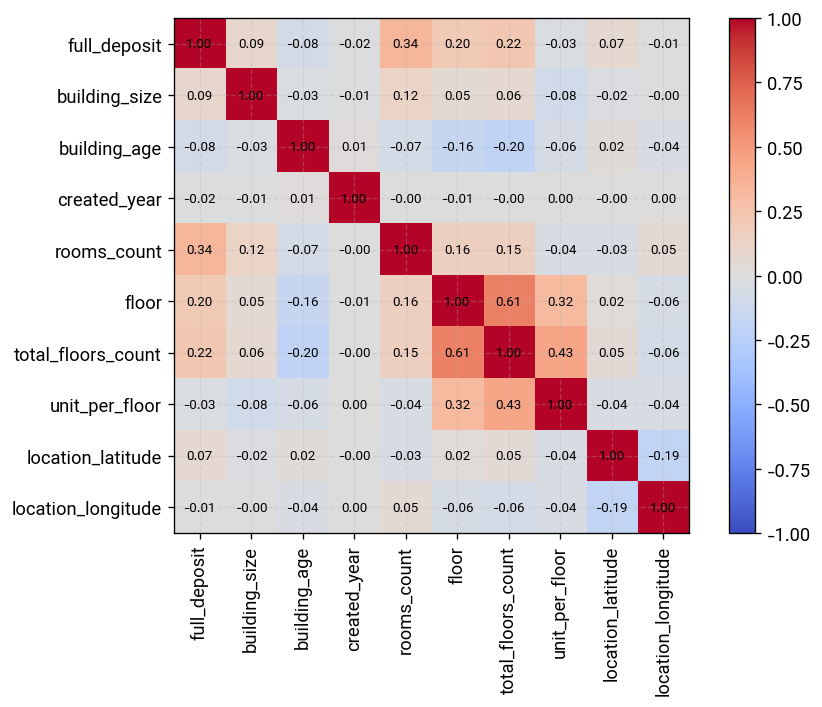

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8,
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [29]:
rent_df.shape

(331206, 19)

### Fill Missing

In [30]:
# Boolean
bool_cols = [
    "has_balcony",
    "is_rebuilt",
    "has_elevator",
    "has_parking",
    "has_warehouse",
]

for col in bool_cols:
    rent_df[col] = rent_df[col].fillna(False)

# Numeric
rent_df["building_size"] = rent_df.groupby("cat3_slug")["building_size"].transform(
    lambda s: s.fillna(s.median())
)

rent_df["rooms_count"] = rent_df.groupby("cat3_slug")["rooms_count"].transform(
    lambda s: s.fillna(s.median())
)

rent_df["floor"] = rent_df.groupby("cat3_slug")["floor"].transform(
    lambda s: s.fillna(s.median())
)

rent_df["total_floors_count"] = rent_df.groupby("cat3_slug")[
    "total_floors_count"
].transform(lambda s: s.fillna(s.median()))

rent_df["unit_per_floor"] = rent_df.groupby("cat3_slug")["unit_per_floor"].transform(
    lambda s: s.fillna(s.median())
)

rent_df["building_age"] = rent_df.groupby("cat3_slug")["building_age"].transform(
    lambda s: s.fillna(s.median())
)

rent_df["location_longitude"] = rent_df.groupby("city_slug")[
    "location_longitude"
].transform(lambda s: s.fillna(s.median()))

rent_df["location_latitude"] = rent_df.groupby("city_slug")[
    "location_latitude"
].transform(lambda s: s.fillna(s.median()))

# Categorical
cat_cols = ["city_slug", "created_month", "cat2_slug", "cat3_slug"]

for col in cat_cols:
    rent_df[col] = rent_df[col].cat.add_categories(["Unknown"]).fillna("Unknown")

In [31]:
rent_df = rent_df.dropna(
    subset=[
        "city_slug",
        "cat3_slug",
        "location_longitude",
        "location_latitude",
        "building_size",
        "rooms_count",
        "building_age",
    ]
)

In [32]:
rent_df.shape

(331202, 19)

### Linear

#### LinearRegression

In [46]:
linearRegression_features = [
    "full_deposit",
    "has_balcony",
    "is_rebuilt",
    "has_elevator",
    "location_longitude",
    "location_latitude",
    "has_parking",
    "has_warehouse",
    "cat3_slug",
    "building_age",
    "created_month",
    "created_year",
    "rooms_count",
    "floor",
    "building_size",
    "cat2_slug",
    "city_slug",
    "total_floors_count",
    "unit_per_floor",
]

In [47]:
X = rent_df.drop(columns=["full_deposit"])
y = rent_df["full_deposit"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=2 / 7,
    random_state=42,
)

cat_cols = X.select_dtypes(include=["category"]).columns.tolist()

num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            num_cols,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        ),
    ]
)

model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("linear", LinearRegression()),
    ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [48]:
y_val_pred = model.predict(X_val)

n = X_val.shape[0]
p = model["preprocessor"].get_feature_names_out().shape[0]

r2 = r2_score(y_val, y_val_pred)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("========== Validation ==========")
print(f"Rows: {len(X_val)}")
print(f"Number of Features: {p}")
print(f"MAE: {mean_absolute_error(y_val, y_val_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred)):,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

========== Validation ==========
Rows: 66241
Number of Features: 429
MAE: 294,180,745
RMSE: 440,514,415
R²: 0.4581
Adjusted R²: 0.4546


#### Ridge Regression

In [50]:
X = rent_df.drop(columns=["full_deposit"])
y = rent_df["full_deposit"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=2 / 7,
    random_state=42,
)

cat_cols = X.select_dtypes(include=["category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            num_cols,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        ),
    ]
)

pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("ridge", Ridge()),
    ]
)

search = BayesSearchCV(
    estimator=pipe,
    search_spaces={
        "ridge__alpha": Real(
            1e-4,
            1e4,
            prior="log-uniform",
        )
    },
    n_iter=20,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train, y_train)

,estimator,"Pipeline(step...e', Ridge())])"
,search_spaces,{'ridge__alpha': Real(low=0.00...m='normalize')}
,optimizer_kwargs,None
,n_iter,20
,scoring,'r2'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,3


In [51]:
y_val_pred = search.predict(X_val)

p = search.best_estimator_["preprocessor"].get_feature_names_out().shape[0]
n = X_val.shape[0]

r2 = r2_score(y_val, y_val_pred)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("========== Validation ==========")
print("Best alpha:", search.best_params_)
print("Best CV R²:", search.best_score_)
print(f"Rows: {len(X_val)}")
print(f"Number of Features: {p}")
print(f"MAE: {mean_absolute_error(y_val, y_val_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred)):,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

========== Validation ==========
Best alpha: OrderedDict({'ridge__alpha': 2.224459696801683})
Best CV R²: 0.45418540840666094
Rows: 66241
Number of Features: 429
MAE: 294,754,186
RMSE: 441,014,850
R²: 0.4569
Adjusted R²: 0.4533


#### Lasso

In [ ]:

X = rent_df.drop(columns=["full_deposit"])
y = rent_df["full_deposit"]

cat_cols = X.select_dtypes(include=["category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            num_cols,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        ),
    ]
)

pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("lasso", Lasso(max_iter=10000)),
    ]
)

search = BayesSearchCV(
    estimator=pipe,
    search_spaces={
        "lasso__alpha": Real(
            1e-5,
            1e3,
            prior="log-uniform",
        )
    },
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train, y_train)

In [ ]:
y_val_pred = search.predict(X_val)

p = search.best_estimator_["preprocessor"].get_feature_names_out().shape[0]
n = X_val.shape[0]

r2 = r2_score(y_val, y_val_pred)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("========== Validation ==========")
print("Best alpha:", search.best_params_)
print("Best CV R²:", search.best_score_)
print(f"Rows: {len(X_val)}")
print(f"Number of Features: {p}")
print(f"MAE: {mean_absolute_error(y_val, y_val_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred)):,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

### Tree Models

#### RandomForestRegressor

In [65]:
rent_df["floor"] = rent_df["floor"].fillna(rent_df["floor"].median()).astype("Int8")

rent_df["total_floors_count"] = (
    rent_df["total_floors_count"]
    .fillna(rent_df["total_floors_count"].median())
    .astype("Int8")
)

rent_df["unit_per_floor"] = (
    rent_df["unit_per_floor"].fillna(rent_df["unit_per_floor"].median()).astype("Int8")
)

In [66]:
X = rent_df.drop(columns=["full_deposit"])
y = rent_df["full_deposit"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=2 / 7,
    random_state=42,
)

X_search, _, y_search, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.20,
    random_state=42,
)

cat_cols = X.select_dtypes(include=["category"]).columns.tolist()

num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
            cat_cols,
        ),
        (
            "num",
            "passthrough",
            num_cols,
        ),
    ]
)

pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

search = BayesSearchCV(
    estimator=pipe,
    search_spaces={
        "rf__n_estimators": Integer(300, 700),
        "rf__max_depth": Integer(15, 40),
        "rf__min_samples_split": Integer(2, 10),
        "rf__min_samples_leaf": Integer(1, 4),
        "rf__max_features": Integer(10, 40),
    },
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)

search.fit(X_search, y_search)

,estimator,Pipeline(step...m_state=42))])
,search_spaces,"{'rf__max_depth': Integer(low=1...m='normalize'), 'rf__max_features': Integer(low=1...m='normalize'), 'rf__min_samples_leaf': Integer(low=1...m='normalize'), 'rf__min_samples_split': Integer(low=2...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,10
,scoring,'r2'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,3


In [67]:
print("Best Params:", search.best_params_)
print("Best CV R²:", search.best_score_)

best_rf = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
                n_estimators=search.best_params_["rf__n_estimators"],
                max_depth=search.best_params_["rf__max_depth"],
                min_samples_split=search.best_params_["rf__min_samples_split"],
                min_samples_leaf=search.best_params_["rf__min_samples_leaf"],
                max_features=search.best_params_["rf__max_features"],
            ),
        ),
    ]
)

best_rf.fit(X_train, y_train)

Best Params: OrderedDict({'rf__max_depth': 33, 'rf__max_features': 38, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 4, 'rf__n_estimators': 620})
Best CV R²: 0.6629544979582668


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [68]:
y_val_pred = best_rf.predict(X_val)

p = best_rf["preprocessor"].get_feature_names_out().shape[0]
n = len(X_val)

r2 = r2_score(y_val, y_val_pred)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n========== Validation ==========")
print(f"Rows: {n}")
print(f"Number of Features: {p}")
print(f"MAE: {mean_absolute_error(y_val, y_val_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred)):,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")


========== Validation ==========
Rows: 66241
Number of Features: 429
MAE: 191,672,647
RMSE: 326,883,492
R²: 0.7016
Adjusted R²: 0.6997


### Boosting

#### XGBRegressor

In [69]:
X = rent_df.drop(columns=["full_deposit"])
y = rent_df["full_deposit"]

X = pd.get_dummies(
    X,
    drop_first=False,
    dtype=np.uint8,
)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=2 / 7,
    random_state=42,
)

X_search, _, y_search, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.20,
    random_state=42,
)

xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

search = BayesSearchCV(
    estimator=xgb,
    search_spaces={
        "n_estimators": Integer(300, 700),
        "max_depth": Integer(4, 10),
        "learning_rate": Real(0.02, 0.20, prior="log-uniform"),
        "subsample": Real(0.70, 1.00),
        "colsample_bytree": Real(0.70, 1.00),
        "min_child_weight": Integer(1, 10),
        "gamma": Real(0.0, 5.0),
        "reg_alpha": Real(1e-6, 10, prior="log-uniform"),
        "reg_lambda": Real(1e-3, 100, prior="log-uniform"),
    },
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)

search.fit(X_search, y_search)

,estimator,"XGBRegressor(...ree=None, ...)"
,search_spaces,"{'colsample_bytree': Real(low=0.7,...m='normalize'), 'gamma': Real(low=0.0,...m='normalize'), 'learning_rate': Real(low=0.02...m='normalize'), 'max_depth': Integer(low=4...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,10
,scoring,'r2'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,3


In [71]:
print("Best Params:", search.best_params_)
print("Best CV R²:", search.best_score_)

best_xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **search.best_params_,
)

best_xgb.fit(
    X_train,
    y_train,
)

Best Params: OrderedDict({'colsample_bytree': 0.8334497536903456, 'gamma': 4.593612608346885, 'learning_rate': 0.025461803033398137, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 481, 'reg_alpha': 1.2250008170155653e-05, 'reg_lambda': 5.724830816786893, 'subsample': 0.8672021269101404})
Best CV R²: 0.6844388047854105


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8334497536903456
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegres

In [72]:
y_pred = best_xgb.predict(X_val)

r2 = r2_score(y_val, y_pred)

adj_r2 = 1 - (1 - r2) * (len(y_val) - 1) / (
    len(y_val) - X.shape[1] - 1
)

print("\n========== Validation ==========")
print("Best Params:", search.best_params_)
print(f"Best CV R²: {search.best_score_:.4f}")
print(f"Rows: {len(X_val)}")
print(f"Number of Features: {X.shape[1]}")
print(f"MAE: {mean_absolute_error(y_val, y_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")


========== Validation ==========
Best Params: OrderedDict({'colsample_bytree': 0.8334497536903456, 'gamma': 4.593612608346885, 'learning_rate': 0.025461803033398137, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 481, 'reg_alpha': 1.2250008170155653e-05, 'reg_lambda': 5.724830816786893, 'subsample': 0.8672021269101404})
Best CV R²: 0.6844
Rows: 66241
Number of Features: 473
MAE: 189,923,296
RMSE: 324,921,513
R²: 0.7052
Adjusted R²: 0.7031


| Model                               |             MAE |            RMSE |         R² | Adjusted R² |
| ----------------------------------- | --------------: | --------------: | ---------: | ----------: |
| **XGBoost + Bayesian Search**       | **189,923,296** | **324,921,513** | **0.7052** |  **0.7031** |
| **Random Forest + Bayesian Search** |     191,672,647 |     326,883,492 |     0.7016 |      0.6997 |
| Ridge Regression                    |     294,754,186 |     441,014,850 |     0.4569 |      0.4533 |
| Linear Regression                   |     294,180,745 |     440,514,415 |     0.4581 |      0.4546 |


### Final Test Evaluation

In [73]:
final_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **search.best_params_,
)

final_model.fit(
    X_train_val,
    y_train_val,
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8334497536903456
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegres

In [74]:
y_test_pred = final_model.predict(X_test)

r2 = r2_score(y_test, y_test_pred)

adj_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X.shape[1] - 1)

print("========== Final Test ==========")
print(f"Rows: {len(X_test)}")
print(f"Number of Features: {X.shape[1]}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

========== Final Test ==========
Rows: 99361
Number of Features: 473
MAE: 189,857,168
RMSE: 324,196,861
R²: 0.7069
Adjusted R²: 0.7055


| Dataset        |             MAE |            RMSE |         R² | Adjusted R² |
| -------------- | --------------: | --------------: | ---------: | ----------: |
| Validation     |     189,923,296 |     324,921,513 |     0.7052 |      0.7031 |
| **Final Test** | **189,857,168** | **324,196,861** | **0.7069** |  **0.7055** |


| Metric | Validation |       Test |
| ------ | ---------: | ---------: |
| MAE    |   189.92 M |   189.86 M |
| RMSE   |   324.92 M |   324.20 M |
| R²     |     0.7052 | **0.7069** |


| Model                                             |             MAE |            RMSE |         R² | Adjusted R² |
| ------------------------------------------------- | --------------: | --------------: | ---------: | ----------: |
| Linear Regression                                 |     294,180,745 |     440,514,415 |     0.4581 |      0.4546 |
| Ridge Regression                                  |     294,754,186 |     441,014,850 |     0.4569 |      0.4533 |
| Random Forest + Bayesian Optimization             |     191,672,647 |     326,883,492 |     0.7016 |      0.6997 |
| **XGBoost + Bayesian Optimization (Final Model)** | **189,857,168** | **324,196,861** | **0.7069** |  **0.7055** |


### Conclusion

This project developed a machine learning model to predict the **full deposit value** of rental properties using real estate advertisements from the Divar platform. The workflow included data cleaning, feature engineering, exploratory data analysis, model training, hyperparameter optimization, and performance evaluation. Several regression models were compared, including Linear Regression, Ridge Regression, Random Forest, and XGBoost.

The experimental results showed that tree-based ensemble methods significantly outperformed linear models. Among all evaluated algorithms, **XGBoost with Bayesian hyperparameter optimization** achieved the best performance, obtaining an **R² of 0.7069**, an **Adjusted R² of 0.7055**, a **MAE of 189.86 million**, and a **RMSE of 324.20 million** on the independent test set. The close agreement between the validation and test results also indicates that the final model generalizes well and does not suffer from significant overfitting.

Overall, the results demonstrate that combining comprehensive data preprocessing, effective feature engineering, and optimized ensemble learning algorithms provides a reliable approach for predicting rental deposit prices. This model can support property valuation and market analysis, while future work may further improve prediction accuracy by incorporating additional economic indicators, spatial information, and more advanced boosting algorithms such as CatBoost or LightGBM.
